# Fund Analysis
This notebook analyzes fund performance relative to the SP500.

In [1]:
# SET THE FUND COLUMN NAME HERE
FUND_NAME = 'sixth_turn'

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Load data
df = pd.read_csv('../data/concat_hf_data.csv')
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')

# Keep only sp500 and target fund columns
fund_col = FUND_NAME
df = df[['sp500', fund_col]].dropna()

# df = df[df.index >= pd.to_datetime('2023-01-01')]

fund = df[fund_col]
sp500 = df['sp500']

# Fetch WTI data
WTI_CHECK = False


if WTI_CHECK:
    import yfinance as yf
    try:
        wti = yf.download('CL=F', start=df.index.min() - pd.Timedelta(days=31), end=df.index.max() + pd.Timedelta(days=31), progress=False)
        if isinstance(wti.columns, pd.MultiIndex):
            wti_close = wti['Close']['CL=F'].to_frame()
        else:
            wti_close = wti[['Close']]
        
        # For monthly data, get the close price at the end of each month
        wti_monthly = wti_close.resample('ME').last()
        wti_returns = wti_monthly.pct_change()
        
        # Realign the index to match df (which uses 1st of month)
        wti_returns.index = wti_returns.index.to_period('M').to_timestamp()
        wti_monthly.index = wti_monthly.index.to_period('M').to_timestamp()
        
        wti_returns.columns = ['wti_return']
        wti_monthly.columns = ['wti_price']
        
        # Merge into df
        df = df.join(wti_monthly).join(wti_returns)
    except Exception as e:
        print(f"Error fetching WTI data: {e}")

df.head()

,sp500,sixth_turn
date,,
2025-03-01,-0.056344,0.0000
2025-04-01,-0.006781,0.0182
2025-05-01,0.062945,-0.0013
2025-06-01,0.050852,0.0146
2025-07-01,0.022443,0.0248


In [3]:
# Dataset Info and Hit Rates
start_date = df.index.min()
end_date = df.index.max()
n_months = len(df)
time_elapsed = end_date - start_date
years_elapsed = time_elapsed.days / 365.25

print("--- Dataset Info ---")
print(f"Start Date: {start_date.date()}")
print(f"End Date:   {end_date.date()}")
print(f"Time Elapsed: {time_elapsed.days} days ({years_elapsed:.2f} years)")
print(f"Total Data Points: {n_months} months")

fund_pos_months = (fund > 0).sum()
sp500_pos_months = (sp500 > 0).sum()
print("\n--- Positive Months (Hit Rates) ---")
print(f"Fund Positive Months:  {fund_pos_months/n_months:.2%} ({fund_pos_months}/{n_months})")
print(f"SP500 Positive Months: {sp500_pos_months/n_months:.2%} ({sp500_pos_months}/{n_months})")

sp500_neg_mask = sp500 < 0
sp500_pos_mask = sp500 > 0
n_sp500_neg = sp500_neg_mask.sum()
n_sp500_pos = sp500_pos_mask.sum()

fund_pos_when_sp500_neg = (fund[sp500_neg_mask] > 0).sum()
fund_neg_when_sp500_pos = (fund[sp500_pos_mask] < 0).sum()
print("\n--- Conditional Hit Rates ---")
print(f"Fund Positive when SP500 Negative: {fund_pos_when_sp500_neg / n_sp500_neg if n_sp500_neg > 0 else np.nan:.2%} ({fund_pos_when_sp500_neg}/{n_sp500_neg})")
print(f"Fund Negative when SP500 Positive: {fund_neg_when_sp500_pos / n_sp500_pos if n_sp500_pos > 0 else np.nan:.2%} ({fund_neg_when_sp500_pos}/{n_sp500_pos})")

--- Dataset Info ---
Start Date: 2025-03-01
End Date:   2026-03-01
Time Elapsed: 365 days (1.00 years)
Total Data Points: 13 months

--- Positive Months (Hit Rates) ---
Fund Positive Months:  84.62% (11/13)
SP500 Positive Months: 69.23% (9/13)

--- Conditional Hit Rates ---
Fund Positive when SP500 Negative: 75.00% (3/4)
Fund Negative when SP500 Positive: 11.11% (1/9)


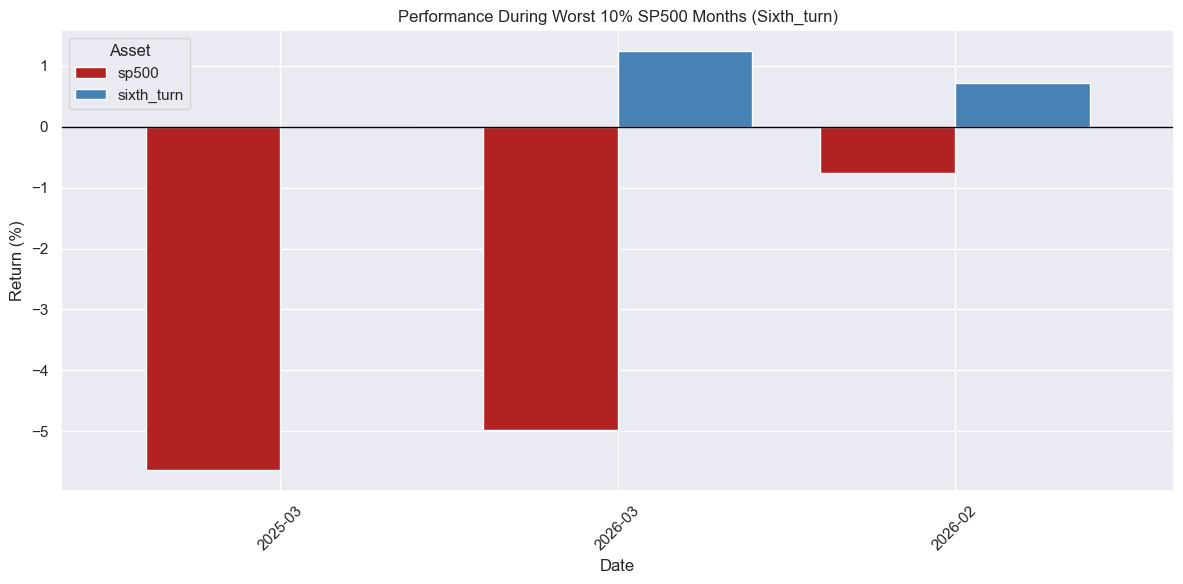

In [4]:
# --- Worst 10% SP500 Months Analysis ---
# Find worst 10% SP500 months
q10_sp500 = sp500.quantile(0.20)
worst_months = df[df['sp500'] <= q10_sp500].copy()

# Sort by SP500 returns ascending
worst_months = worst_months.sort_values(by='sp500', ascending=True)

# Prepare data for plotting
plot_data = worst_months[['sp500', fund_col]].copy()
plot_data.index = plot_data.index.strftime('%Y-%m') # Format dates for x-axis
plot_data = plot_data * 100 # Convert to percentage

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))

# Use explicit color mapping to avoid any confusion in the legend
colors = {'sp500': 'firebrick', fund_col: 'steelblue'}
plot_data.plot(kind='bar', ax=ax, width=0.8, color=[colors[c] for c in plot_data.columns])

plt.title(f'Performance During Worst 10% SP500 Months ({fund_col.capitalize()})')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)

# Let pandas handle the legend to ensure it matches the plotted data perfectly
plt.legend(title='Asset')
plt.tight_layout()
plt.show()

In [5]:
# Trading Metrics
mean_ret = fund.mean() * 12
vol = fund.std() * np.sqrt(12)
sharpe = mean_ret / vol if vol != 0 else np.nan

# CAGR
cum_ret = (1 + fund).prod()
n_years = n_months / 12
cagr = cum_ret**(1/n_years) - 1

# Max Drawdown
cum_wealth = (1 + fund).cumprod()
peak = cum_wealth.cummax()
drawdown = (cum_wealth - peak) / peak
max_drawdown = drawdown.min()

# Calmar Ratio
calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

print(f"--- Trading Metrics (n={n_months} months) ---")
print(f"Annualized Mean Return: {mean_ret:.4f}")
print(f"Annualized Volatility:  {vol:.4f}")
print(f"Sharpe Ratio:           {sharpe:.4f}")
print(f"CAGR:                   {cagr:.4f}")
print(f"Max Drawdown:           {max_drawdown:.4f}")
print(f"Calmar Ratio:           {calmar:.4f}")

--- Trading Metrics (n=13 months) ---
Annualized Mean Return: 0.2266
Annualized Volatility:  0.1042
Sharpe Ratio:           2.1739
CAGR:                   0.2459
Max Drawdown:           -0.0013
Calmar Ratio:           189.1817


In [6]:
# Joint Metrics
pearson_corr = fund.corr(sp500, method='pearson')
spearman_corr = fund.corr(sp500, method='spearman')

# Bootstrap for correlations (1000 iterations, 95% CI -> 5% safety interval)
def bootstrap_corr(x, y, method='pearson', block_size=1, iters=1000):
    np.random.seed(42) # For reproducibility
    n = len(x)
    corrs = []
    indices = np.arange(n)
    for _ in range(iters):
        if block_size == 1:
            idx = np.random.choice(indices, size=n, replace=True)
        else:
            num_blocks = int(np.ceil(n / block_size))
            block_starts = np.random.choice(n - block_size + 1, size=num_blocks, replace=True)
            idx = [i for start in block_starts for i in range(start, start + block_size)][:n]
        x_samp = x.iloc[idx]
        y_samp = y.iloc[idx]
        corrs.append(x_samp.corr(y_samp, method=method))
    return np.nanpercentile(corrs, 2.5), np.nanpercentile(corrs, 97.5)

pearson_std_ci = bootstrap_corr(fund, sp500, method='pearson', block_size=1)
pearson_blk_ci = bootstrap_corr(fund, sp500, method='pearson', block_size=3)
spearman_std_ci = bootstrap_corr(fund, sp500, method='spearman', block_size=1)
spearman_blk_ci = bootstrap_corr(fund, sp500, method='spearman', block_size=3)

X = sm.add_constant(sp500)
model = sm.OLS(fund, X).fit()
alpha = model.params['const'] * 12
beta = model.params['sp500']
alpha_tstat = model.tvalues['const']
beta_tstat = model.tvalues['sp500']

print(f"--- Joint Metrics (n={n_months} months) ---")
print(f"Pearson Correlation:  {pearson_corr:.4f}")
print(f"  - 95% CI (Standard Bootstrap): [{pearson_std_ci[0]:.4f}, {pearson_std_ci[1]:.4f}]")
print(f"  - 95% CI (Block=3 Bootstrap):  [{pearson_blk_ci[0]:.4f}, {pearson_blk_ci[1]:.4f}]")
print(f"Spearman Correlation: {spearman_corr:.4f}")
print(f"  - 95% CI (Standard Bootstrap): [{spearman_std_ci[0]:.4f}, {spearman_std_ci[1]:.4f}]")
print(f"  - 95% CI (Block=3 Bootstrap):  [{spearman_blk_ci[0]:.4f}, {spearman_blk_ci[1]:.4f}]")
print(f'-'*40)
print(f"Regression Alpha (Annualized): {alpha:.4f} (t-stat: {alpha_tstat:.4f})")
print(f"Regression Beta:               {beta:.4f} (t-stat: {beta_tstat:.4f})")
model.summary()

--- Joint Metrics (n=13 months) ---
Pearson Correlation:  -0.0169
  - 95% CI (Standard Bootstrap): [-0.4368, 0.4595]
  - 95% CI (Block=3 Bootstrap):  [-0.6874, 0.1841]
Spearman Correlation: 0.0000
  - 95% CI (Standard Bootstrap): [-0.5952, 0.6515]
  - 95% CI (Block=3 Bootstrap):  [-0.8261, 0.4311]
----------------------------------------
Regression Alpha (Annualized): 0.2282 (t-stat: 2.1096)
Regression Beta:               -0.0147 (t-stat: -0.0560)


/opt/anaconda3/envs/investmentepfl/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             sixth_turn   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.091
Method:                 Least Squares   F-statistic:                  0.003133
Date:                Mon, 13 Jul 2026   Prob (F-statistic):              0.956
Time:                        18:29:28   Log-Likelihood:                 27.621
No. Observations:                  13   AIC:                            -51.24
Df Residuals:                      11   BIC:                            -50.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0190      0.009      2.110      0.059      -0.001       0.039
sp500         -0.0147      0.263     -0.056      0.956      -0.593       0.563
==============================================================================
Omnibus:                       26.945   Durbin-Watson:                   2.430
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.222
Skew:                           2.530   Prob(JB):                     2.74e-07
Kurtosis:                       8.494   Cond. No.                         30.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
# Beta of the fund with WTI returns
if 'wti_return' in df.columns and df['wti_return'].notna().sum() > 10:
    wti_clean = df[['wti_return', fund_col]].dropna()
    X_wti = sm.add_constant(wti_clean['wti_return'])
    model_wti = sm.OLS(wti_clean[fund_col], X_wti).fit()
    
    alpha_wti = model_wti.params['const'] * 12
    beta_wti = model_wti.params['wti_return']
    alpha_wti_tstat = model_wti.tvalues['const']
    beta_wti_tstat = model_wti.tvalues['wti_return']
    
    print(f"--- WTI Joint Metrics (n={len(wti_clean)} months) ---")
    print(f"Regression Alpha (Annualized): {alpha_wti:.4f} (t-stat: {alpha_wti_tstat:.4f})")
    print(f"Regression Beta (WTI):         {beta_wti:.4f} (t-stat: {beta_wti_tstat:.4f})")
else:
    print("WTI returns not available or not enough data points.")

WTI returns not available or not enough data points.


In [8]:
# Upside / Downside Capture
up_months = df[sp500_pos_mask]
down_months = df[sp500_neg_mask]

up_capture = up_months[fund_col].mean() / up_months['sp500'].mean()
down_capture = down_months[fund_col].mean() / down_months['sp500'].mean()

print("--- Capture Ratios ---")
print(f"Upside Capture:   {up_capture:.4f} (n={len(up_months)})")
print(f"Downside Capture: {down_capture:.4f} (n={len(down_months)})")

--- Capture Ratios ---
Upside Capture:   0.8876 (n=9)
Downside Capture: -0.3136 (n=4)


In [9]:
# Conditional Metrics: Positive / Negative SP500 Months
model_up = sm.OLS(up_months[fund_col], sm.add_constant(up_months['sp500'])).fit()
print(f"--- Up Months Metrics (n={len(up_months)}) ---")
print(f"Up Alpha (Annualized): {model_up.params['const'] * 12:.4f} (t-stat: {model_up.tvalues['const']:.4f})")
print(f"Up Beta:               {model_up.params['sp500']:.4f} (t-stat: {model_up.tvalues['sp500']:.4f})")

print(f"\n--- Down Months Metrics (n={len(down_months)}) ---")
model_down = sm.OLS(down_months[fund_col], sm.add_constant(down_months['sp500'])).fit()
print(f"Down Alpha (Annualized): {model_down.params['const'] * 12:.4f} (t-stat: {model_down.tvalues['const']:.4f})")
print(f"Down Beta:               {model_down.params['sp500']:.4f} (t-stat: {model_down.tvalues['sp500']:.4f})")

--- Up Months Metrics (n=9) ---
Up Alpha (Annualized): 0.5167 (t-stat: 2.2874)
Up Beta:               -0.7686 (t-stat: -1.3307)

--- Down Months Metrics (n=4) ---
Down Alpha (Annualized): 0.1718 (t-stat: 2.2078)
Down Beta:               0.1614 (t-stat: 0.9447)


In [10]:
# Correlation when SP500 is lower than 1st decile and 1st quartile
decile_1 = sp500.quantile(0.10)
df_d1 = df[df['sp500'] < decile_1]
d1_pearson = df_d1[fund_col].corr(df_d1['sp500'], method='pearson')
d1_spearman = df_d1[fund_col].corr(df_d1['sp500'], method='spearman')

quartile_1 = sp500.quantile(0.25)
df_q1 = df[df['sp500'] < quartile_1]
q1_pearson = df_q1[fund_col].corr(df_q1['sp500'], method='pearson')
q1_spearman = df_q1[fund_col].corr(df_q1['sp500'], method='spearman')

print("--- Tail Correlations ---")
print(f"SP500 < 1st Decile   | Pearson: {d1_pearson:.4f}, Spearman: {d1_spearman:.4f} (n={len(df_d1)})")
print(f"SP500 < 1st Quartile | Pearson: {q1_pearson:.4f}, Spearman: {q1_spearman:.4f} (n={len(df_q1)})")

--- Tail Correlations ---
SP500 < 1st Decile   | Pearson: 1.0000, Spearman: 1.0000 (n=2)
SP500 < 1st Quartile | Pearson: 0.2153, Spearman: 0.5000 (n=3)


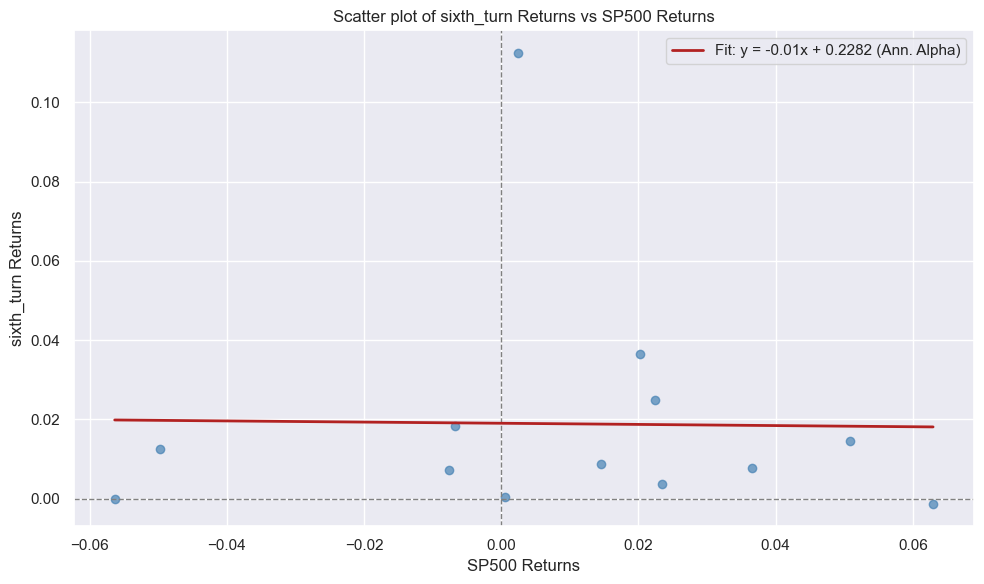

In [11]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(sp500, fund, alpha=0.7, color='steelblue')
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('SP500 Returns')
plt.ylabel(f'{fund_col} Returns')
plt.title(f'Scatter plot of {fund_col} Returns vs SP500 Returns')

# Regression line
x_vals = np.linspace(sp500.min(), sp500.max(), 100)
y_vals = model.params['sp500'] * x_vals + model.params['const']
plt.plot(x_vals, y_vals, color='firebrick', linewidth=2, label=f"Fit: y = {model.params['sp500']:.2f}x + {model.params['const'] * 12:.4f} (Ann. Alpha)")

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Rolling Metrics (12-month and 24-month)
roll_corr_12 = fund.rolling(12).corr(sp500)
roll_corr_24 = fund.rolling(24).corr(sp500)

X_roll = sm.add_constant(sp500)
roll_model_12 = RollingOLS(fund, X_roll, window=12).fit()
roll_alpha_12 = roll_model_12.params['const'] * 12
roll_beta_12 = roll_model_12.params['sp500']

roll_model_24 = RollingOLS(fund, X_roll, window=24).fit()
roll_alpha_24 = roll_model_24.params['const'] * 12
roll_beta_24 = roll_model_24.params['sp500']

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

# Rolling Correlation
axes[0].plot(roll_corr_12, label='12-Month', color='steelblue')
axes[0].plot(roll_corr_24, label='24-Month', color='firebrick')
axes[0].axhline(0, color='grey', linestyle='--')
axes[0].set_title(f'Rolling Correlation between {fund_col} and SP500')
axes[0].legend()

# Rolling Beta
axes[1].plot(roll_beta_12, label='12-Month', color='steelblue')
axes[1].plot(roll_beta_24, label='24-Month', color='firebrick')
axes[1].axhline(1, color='grey', linestyle='--')
axes[1].axhline(0, color='grey', linestyle=':')
axes[1].set_title(f'Rolling Beta of {fund_col} relative to SP500')
axes[1].legend()

# Rolling Alpha
axes[2].plot(roll_alpha_12, label='12-Month', color='steelblue')
axes[2].plot(roll_alpha_24, label='24-Month', color='firebrick')
axes[2].axhline(0, color='grey', linestyle='--')
axes[2].set_title(f'Rolling Annualized Alpha of {fund_col} relative to SP500')
axes[2].legend()

plt.tight_layout()
plt.show()

IndexError: index 23 is out of bounds for axis 0 with size 13

In [ ]:
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.correlation_tools import corr_nearest

class FoHFDataAnalyzer:
    """
    Expert quantitative module to diagnose serial correlation, evaluate dependencies, 
    and construct a worst-case scenario co-dependence matrix.
    """
    def __init__(self, data, alpha=0.05, block_size=3, bootstrap_iters=1000):
        self.data = data.dropna()
        self.alpha = alpha
        self.block_size = block_size
        self.iters = bootstrap_iters
        self.n = len(self.data)
        self.columns = self.data.columns
        
        if self.n < 36:
            warnings.warn(f"Dataset has only {self.n} monthly observations. Results may lack statistical power (recommended >= 36).")
            
    def check_autocorrelation(self, lags=[1, 3]):
        print("--- 1. Individual Autocorrelation Diagnostic (Ljung-Box & Box-Pierce) ---")
        for col in self.columns:
            res = acorr_ljungbox(self.data[col], lags=lags, boxpierce=True, return_df=True)
            print(f"\nFund/Asset: {col}")
            print(res)
            for lag in lags:
                pval = res.loc[lag, 'lb_pvalue']
                if pval < self.alpha:
                    print(f"  -> WARNING: {col} exhibits significant serial correlation at Lag {lag} (p-value={pval:.4f}).")
                else:
                    print(f"  -> {col} passes at Lag {lag} (no significant serial correlation).")
                    
    def pairwise_correlation_analysis(self):
        print("\n--- 2. Pairwise Correlation & Bootstrap Engine ---")
        print("Interpretation Framework:")
        print("  * Pearson (r): Captures linear co-movement and dollar-exposure risks, sensitive to tail outliers.")
        print("  * Spearman (\u03c1): Captures monotonic rank co-movement, robust to outliers/non-linear regime alignment.")
        print("  * If r > \u03c1: Relationship is driven by synchronized extreme tail events.")
        print("  * If \u03c1 > r: Structural co-movement, but decouples or non-linearly saturates at extremes.")
        
        pearson_mat = self.data.corr(method='pearson')
        spearman_mat = self.data.corr(method='spearman')
        
        print("\nBaseline Pearson Matrix:")
        print(pearson_mat)
        print("\nBaseline Spearman Matrix:")
        print(spearman_mat)
        
        self.pearson_mat = pearson_mat
        return pearson_mat, spearman_mat
        
    def _block_bootstrap_upper_bound(self, x, y):
        # Moving Block Bootstrap to preserve serial dependencies
        np.random.seed(42)
        corrs = []
        for _ in range(self.iters):
            num_blocks = int(np.ceil(self.n / self.block_size))
            block_starts = np.random.choice(self.n - self.block_size + 1, size=num_blocks, replace=True)
            idx = [i for start in block_starts for i in range(start, start + self.block_size)][:self.n]
            corrs.append(x.iloc[idx].corr(y.iloc[idx], method='pearson'))
        return np.nanpercentile(corrs, 100 * (1 - self.alpha / 2)) # upper bound of CI

    def construct_worst_case_matrix(self):
        print("\n--- 3. Worst-Case Scenario Co-Dependence Matrix ---")
        k = len(self.columns)
        raw_matrix = np.eye(k)
        
        for i in range(k):
            for j in range(i + 1, k):
                col_x, col_y = self.columns[i], self.columns[j]
                upper_bound = self._block_bootstrap_upper_bound(self.data[col_x], self.data[col_y])
                raw_matrix[i, j] = upper_bound
                raw_matrix[j, i] = upper_bound
                
        print("Raw Upper-Bound Correlation Matrix (May not be PSD):")
        raw_df = pd.DataFrame(raw_matrix, index=self.columns, columns=self.columns)
        print(raw_df)
        
        valid_matrix = corr_nearest(raw_matrix)
        valid_df = pd.DataFrame(valid_matrix, index=self.columns, columns=self.columns)
        print("\nMathematically Valid Nearest Correlation Matrix (PSD):")
        print(valid_df)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.heatmap(self.pearson_mat, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
        axes[0].set_title('Baseline Pearson Matrix')
        
        sns.heatmap(valid_df, annot=True, cmap='Reds', vmin=-1, vmax=1, ax=axes[1])
        axes[1].set_title('Worst-Case Correlation Matrix (PSD)')
        
        plt.tight_layout()
        plt.show()
        return valid_df


--- 1. Individual Autocorrelation Diagnostic (Ljung-Box & Box-Pierce) ---

Fund/Asset: sp500
    lb_stat  lb_pvalue   bp_stat  bp_pvalue
1  2.612091   0.106052  2.574417   0.108604
3  4.916106   0.178044  4.832272   0.184499
  -> sp500 passes at Lag 1 (no significant serial correlation).
  -> sp500 passes at Lag 3 (no significant serial correlation).

Fund/Asset: mw_opportunities
    lb_stat  lb_pvalue   bp_stat  bp_pvalue
1  0.535734   0.464206  0.528007   0.467446
3  0.719206   0.868677  0.707071   0.871540
  -> mw_opportunities passes at Lag 1 (no significant serial correlation).
  -> mw_opportunities passes at Lag 3 (no significant serial correlation).

--- 2. Pairwise Correlation & Bootstrap Engine ---
Interpretation Framework:
  * Pearson (r): Captures linear co-movement and dollar-exposure risks, sensitive to tail outliers.
  * Spearman (ρ): Captures monotonic rank co-movement, robust to outliers/non-linear regime alignment.
  * If r > ρ: Relationship is driven by synchronized e

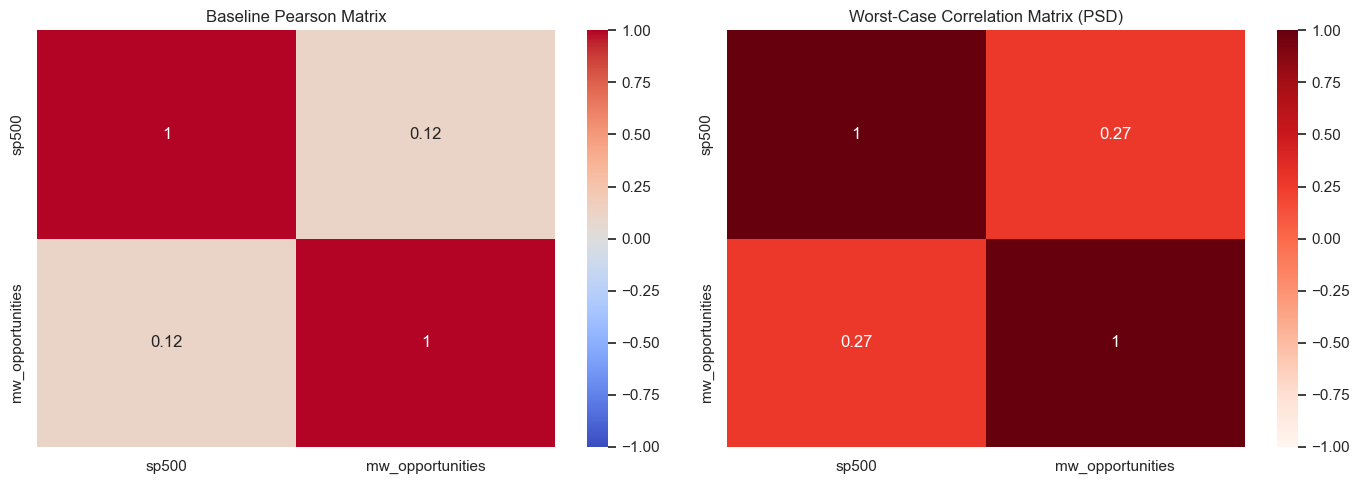

In [ ]:
# Execute the new Quantitative FoHF Analyzer Workflow
analyzer = FoHFDataAnalyzer(df, alpha=0.05, block_size=3)
analyzer.check_autocorrelation(lags=[1, 3])
_, _ = analyzer.pairwise_correlation_analysis()
worst_case_df = analyzer.construct_worst_case_matrix()